# Day 3: ETL Pipelines + Pandas Data Cleaning + APIs

In [26]:
!pip install requests --quiet                 # (--quiet flag) suppresses the installation output so our notebook looks clean
import pandas as pd                           # Data Manipulation library
import numpy as np                            # numerical operations library
import requests                               # standard python library for making HTTP API calls
import matplotlib.pyplot as plt               # Chart library
import warnings                               # control warning messages generated by programs
warnings.filterwarnings('ignore')
print('All libraries imported successfully')
print(f'pandas:{pd.__version__}')
print(f'requests:{requests.__version__}')

All libraries imported successfully
pandas:2.2.2
requests:2.32.4


In [27]:
raw_df=pd.read_csv("/content/messy_sales_data.csv")       # read dataset

In [28]:
print(f'Raw data loaded: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
print(f'Columns: {raw_df.columns.tolist()}')
print('\n First 5 rows')
raw_df.head()

Raw data loaded: 30 rows, 9 columns
Columns: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'order_date', 'city', 'sales_rep']

 First 5 rows


,order_id,customer_name,product,category,quantity,unit_price,order_date,city,sales_rep
0,1001,Ramesh Kumar,Laptop,Electronics,2.0,45000,2024-01-05,Mumbai,Anil Sharma
1,1002,Priya Nair,NaN,Electronics,1.0,15000,2024-01-07,Delhi,Sunita Rao
2,1003,AMIT VERMA,Keyboard,Accessories,3.0,1200,2024-01-08,Bangalore,Anil Sharma
3,1004,Sunita Patel,Monitor,Electronics,NaN,22000,2024-01-10,Chennai,Ravi Kumar
4,1005,Ramesh Kumar,Laptop,Electronics,2.0,45000,2024-01-05,Mumbai,Anil Sharma


In [29]:
raw_df.tail()        # last 5 rows

,order_id,customer_name,product,category,quantity,unit_price,order_date,city,sales_rep
25,1026,NaN,Headphones,Electronics,1.0,3500,2024-02-14,Mumbai,Ravi Kumar
26,1027,Rekha Nair,Monitor,NaN,2.0,22000,2024-02-15,Kochi,Anil Sharma
27,1028,Harish Pillai,Laptop,Electronics,3.0,45000,2024-02-18,Thiruvananthapuram,Ravi Kumar
28,1029,Sanjay Dubey,USB Hub,Accessories,10.0,600,2024-02-20,Allahabad,Sunita Rao
29,1030,Kavya Nambiar,Webcam,Accessories,NaN,2500,2024-02-22,Thrissur,Anil Sharma


In [30]:
print('='*60)
print("DATA QUALITY REPORTS")
print('='*60,"\n")

print("[1] MISSING VALUES PER COLUMN:")
print('-'*40)
print(raw_df.isnull().sum(),"\n")

print("[2] DUPLICATE ROWS:",{raw_df.duplicated().sum()})
print('-'*40)

print("\n[3] DATA TYPES")
print('-'*40)
print(raw_df.dtypes,'\n')

print("[4] UNIQUE CATEGORIES",raw_df["category"].unique())
print('-'*40)

print("\n[5] SAMPLE CUSTOMER NAMES",raw_df["customer_name"].dropna().unique()[:6])        # delete null value, only unique values (first 6)
print('-'*40)

print("\n[6] SAMPLE order_date values",raw_df["order_date"].unique()[:6])
print('-'*40)


DATA QUALITY REPORTS

[1] MISSING VALUES PER COLUMN:
----------------------------------------
order_id         0
customer_name    2
product          1
category         1
quantity         3
unit_price       0
order_date       0
city             0
sales_rep        0
dtype: int64 

[2] DUPLICATE ROWS: {np.int64(0)}
----------------------------------------

[3] DATA TYPES
----------------------------------------
order_id           int64
customer_name     object
product           object
category          object
quantity         float64
unit_price         int64
order_date        object
city              object
sales_rep         object
dtype: object 

[4] UNIQUE CATEGORIES ['Electronics' 'Accessories' nan]
----------------------------------------

[5] SAMPLE CUSTOMER NAMES ['Ramesh Kumar' 'Priya Nair' 'AMIT VERMA' 'Sunita Patel' 'kiran mehta'
 'Deepak Singh']
----------------------------------------

[6] SAMPLE order_date values ['2024-01-05' '2024-01-07' '2024-01-08' '2024-01-10' '07-01-2024

### TRANSFORM: Fix All Data Quality Issues

In [31]:

df= raw_df.copy()
print("Working copy created:",{df.shape})
print("raw_df is untouched")

Working copy created: {(30, 9)}
raw_df is untouched


In [32]:
print('Before fixing nulls',df.isnull().sum().sum(),'total missing values')

df["customer_name"]= df["customer_name"].fillna("UnknownCustomer")

median_qty = df["quantity"].median()
df['quantity'].fillna(median_qty, inplace=True)
print(f'Filled missing quantity with median: {median_qty}')

df["category"].fillna("UnCategorized",inplace=True)
print('After fixing nulls',df.isnull().sum().sum(),'total missing values')


Before fixing nulls 7 total missing values
Filled missing quantity with median: 2.0
After fixing nulls 1 total missing values


In [33]:
print(f'Before deduplication:,{len(df)},rows')
print(f'Duplicate rows,{df.duplicated().sum()}')

print("\n Duplicate rows:")
print( df[df.duplicated(keep=False)][['order_id', 'customer_name', 'product', 'order_date']])

df.drop_duplicates(inplace=True)
print(f'\nAfter Duplication:{len(df)},rows')
print(f'Rows Removed:{len(raw_df)-len(df)}')


Before deduplication:,30,rows
Duplicate rows,0

 Duplicate rows:
Empty DataFrame
Columns: [order_id, customer_name, product, order_date]
Index: []

After Duplication:30,rows
Rows Removed:0


In [34]:
print('Sample dates before parsing:')
print(df['order_date'].tail(8).tolist())

df['order_date']=pd.to_datetime(
    df['order_date'],          # select order_date and convert into datetime format
    dayfirst= False,           # date format like mm/dd/yyyy or yyyy/mm/dd
    errors='coerce'            # invalid dates are converted into NaT
)


Sample dates before parsing:
['2024-01-15', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-18', '2024-02-20', '2024-02-22']


In [35]:
nat_count = df['order_date'].isnull().sum()
print(f'\nUnparsable dates(NaT):{nat_count}') # number of dates that could not be converted

df['year']=df['order_date'].dt.year            # Extract year from order_date column
df["month"]=df['order_date'].dt.month
df['month_name']=df['order_date'].dt.strftime('%B')

print('\nSample dates after parsing')
print(df[['order_date','year','month','month_name']].head(5))


Unparsable dates(NaT):2

Sample dates after parsing
  order_date    year  month month_name
0 2024-01-05  2024.0    1.0    January
1 2024-01-07  2024.0    1.0    January
2 2024-01-08  2024.0    1.0    January
3 2024-01-10  2024.0    1.0    January
4 2024-01-05  2024.0    1.0    January


# strftime() in Python/Pandas


`strftime` = **String Format Time**

Used to convert date/time values into formatted string output.

**Example**

```python
df['month_name'] = df['order_date'].dt.strftime('%B')
```

**Output**

| order_date | month_name |
| ---------- | ---------- |
| 2026-05-27 | May        |
| 2026-01-10 | January    |

---

**Common Format Codes**

| Format Code | Meaning            | Example Output |
| ----------- | ------------------ | -------------- |
| `%Y`        | Full Year          | 2026           |
| `%y`        | Short Year         | 26             |
| `%m`        | Month Number       | 05             |
| `%B`        | Full Month Name    | May            |
| `%b`        | Short Month Name   | May            |
| `%d`        | Day Number         | 27             |
| `%A`        | Full Weekday Name  | Tuesday        |
| `%a`        | Short Weekday Name | Tue            |

---

**Custom Date Format**

```python
df['formatted_date'] = df['order_date'].dt.strftime('%d-%m-%Y')
```

Output:

```python
27-05-2026
```

---


In [36]:
print("Before standardization:",df['customer_name'].unique()[:6])
df['customer_name']=(
    df['customer_name'].str.strip().str.title()
)
print("After standardization:",df['customer_name'].unique()[:6])


Before standardization: ['Ramesh Kumar' 'Priya Nair' 'AMIT VERMA' 'Sunita Patel' 'kiran mehta'
 'Deepak Singh']
After standardization: ['Ramesh Kumar' 'Priya Nair' 'Amit Verma' 'Sunita Patel' 'Kiran Mehta'
 'Deepak Singh']


In [37]:
print(f'\nBefore keyboard rows with Electronics category')
wrong_mask = (df['product']=='Keyboard')&(df['category']=='Electronics')
print(df[wrong_mask][['product','category']])
df.loc[wrong_mask,'category']='Accessories'
print(f'\nAfter Fix: Unique categories:',df['category'].unique())


Before keyboard rows with Electronics category
     product     category
23  Keyboard  Electronics

After Fix: Unique categories: ['Electronics' 'Accessories' 'UnCategorized']


In [38]:
df['quantity']=pd.to_numeric(df["quantity"],errors='coerce').astype(int)
df['unit_price']=pd.to_numeric(df['unit_price'],errors='coerce')

df['revenue']=df['quantity']*df['unit_price']

print('Revenue column created: ')
print(df[['customer_name','product','unit_price','quantity','revenue']].head(5))
print(f'\n Total Revenue across all orders:{df['revenue'].sum()}')

Revenue column created: 
  customer_name   product  unit_price  quantity  revenue
0  Ramesh Kumar    Laptop       45000         2    90000
1    Priya Nair       NaN       15000         1    15000
2    Amit Verma  Keyboard        1200         3     3600
3  Sunita Patel   Monitor       22000         2    44000
4  Ramesh Kumar    Laptop       45000         2    90000

 Total Revenue across all orders:818000


In [39]:
print("="*55)
print('POST-CLEANING VALIDATION REPORT')
print("="*55)
print(f'Original rows  :{len(raw_df)}')
print(f'Cleaned rows   :{len(df)}')
print(f'Rows removed   :{len(raw_df)-len(df)}(duplicates)')
print(f'Missing values :{df.isnull().sum().sum()}')
print(f'Duplicates     :{df.duplicated().sum()}')
print(f'Date nulls     :{df["order_date"].isnull().sum()}')
print(f'Revenue NaN    :{df["revenue"].isnull().sum()}')
print(f'Categories     :{sorted(df["category"].unique())}')
print("="*55)

all_clean =( df.isnull().sum().sum()==0 and
            df.duplicated().sum()==0)
print(f'DATA IS CLEAN: {all_clean}')

POST-CLEANING VALIDATION REPORT
Original rows  :30
Cleaned rows   :30
Rows removed   :0(duplicates)
Missing values :9
Duplicates     :0
Date nulls     :2
Revenue NaN    :0
Categories     :['Accessories', 'Electronics', 'UnCategorized']
DATA IS CLEAN: False


### TRANSFORM: Analyze Cleaned Data with groupby()


In [40]:
product_rev=(
    df.groupby('product')['revenue'].sum().reset_index().sort_values('revenue',ascending=False)
)
# .reser_index() - make product a regular column (not an index)
print('Revenue by Product:')
print(product_rev.to_string(index=False))

category_summary= df.groupby('category').agg(
    total_revenue=('revenue','sum'),
    avg_order_value= ('revenue','mean'),
    num_orders=('order_id','count'),
    unique_products = ('product','nunique')
).round(2).reset_index()

print('\nCategory Summary:')
print(category_summary.to_string(index=False))

Revenue by Product:
   product  revenue
    Laptop   540000
   Monitor   154000
Headphones    28000
     Mouse    20800
  Keyboard    20400
    Webcam    20000
   USB Hub    19800

Category Summary:
     category  total_revenue  avg_order_value  num_orders  unique_products
  Accessories          81000          5785.71          14                4
  Electronics         693000         46200.00          15                3
UnCategorized          44000         44000.00           1                1


### LOAD: Save Cleaned Data

In [41]:
df.to_csv('clean_sales_data.csv',index=False)

print('Cleaned data saved to: clean_sales_data.csv')
print(f'Final dataset:{df.shape[0]} rows {df.shape[1]} columns')
print('\nETL Pipeline for Sales Data:COMPLETE')
print('EXTRACT -> messy_sales_data.csv loaded')
print('TRANSFORM -> nulls fixed, dupes removed, dates parsed, names standardized')
print('LOAD -> clean_sales_data.csv saved')


Cleaned data saved to: clean_sales_data.csv
Final dataset:30 rows 13 columns

ETL Pipeline for Sales Data:COMPLETE
EXTRACT -> messy_sales_data.csv loaded
TRANSFORM -> nulls fixed, dupes removed, dates parsed, names standardized
LOAD -> clean_sales_data.csv saved


# Weather API ETL Pipeline


>  An API lets one software talk to another. You send a request, it sends back data.



In [42]:
API_KEY= '49a0b689f91a33ef8bf2149d7fc5f9ba'                  # unique key by OpenWeatherMap, Authentication

BASE_URL= 'https://api.openweathermap.org/data/2.5/weather'  # API endpoint , request sent , return current weather data

CITIES=['Mumbai','Delhi','Banglore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']  # store values , access using index
print(f'API configured for {len(CITIES)} cities')            # returns total number of cities
print(f'Cities: {CITIES}')                                   # prints all cities
print('\n IMPORTANT: Replace YOUR_API_KEY_HERE with your actual key before running.')

API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Banglore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

 IMPORTANT: Replace YOUR_API_KEY_HERE with your actual key before running.


In [43]:
from pandas.core.arrays.categorical import NoNewAttributesMixin
def fetch_weather(city,api_key):           # function to fetch weather data for one city,
  params={                                 # parameters ->sent to API
      'q' : city,
      'appid' :api_key,
      'units' : 'metric'                   # Celsius ->without metric temperature is returned in Kelvin
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout=10)    #Get request , wait only for 10s for the server response
    if response.status_code ==200:         # SUCCESS
      data= response.json()                # JSON format into Python Dictionary
      return {                             # returns dictionary
          'city' : city,
          'temperature' : round(data['main']['temp'],1),
          'feels_like' : round(data['main']['feels_like'],1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' :data['weather'][0]['description'].title(),
          'visibility': data.get('visibility',0)          # if visibility exists: 5000, else 0(no error occurs)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get("message","unknown error")}')
      return None
  except requests.exceptions.ConnectionError:             # Internet disconnected, DNS problem
    print(f' CONNECTION ERROR for {city}=check internet connection')
    return None
  except requests.exceptions.Timeout:                     # when API doesn't response within 10s
    print(f' TIMEOUT for {city} - API did not respond in 10 seconds')
    return None

print('Calling Weather API...')
weather_records =[]

for city in CITIES:                                       # loop
  print(f' Fetching: {city}..', end=' ')
  record = fetch_weather(city,API_KEY)                    # get weather details for a city
  if record :
    weather_records.append(record)
    print(f'{record['temperature']}°C,{record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')


Calling Weather API...
 Fetching: Mumbai.. 31.0°C,Haze
 Fetching: Delhi.. 29.1°C,Haze
 Fetching: Banglore..  ERROR 404 for Banglore: city not found
FAILED
 Fetching: Chennai.. 31.0°C,Haze
 Fetching: Hyderabad.. 32.2°C,Haze
 Fetching: Kolkata.. 30.0°C,Haze
 Fetching: Pune.. 28.6°C,Scattered Clouds
 Fetching: Jaipur.. 24.6°C,Haze

Successfully fetched: 7/8 cities


Fallback data means backup data that your program uses when the real API data cannot be fetched.

In [44]:
if len(weather_records)==0:
  print('Using fallback weather data (API not available)')
  weather_records = [
        {'city':'Mumbai',    'temperature':32.5,'feels_like':36.0,'humidity':78,'pressure':1009,'wind_speed':5.2,'condition':'Partly Cloudy','visibility':8},
        {'city':'Delhi',     'temperature':38.2,'feels_like':41.0,'humidity':35,'pressure':1002,'wind_speed':3.8,'condition':'Clear Sky',    'visibility':10},
        {'city':'Bangalore', 'temperature':26.1,'feels_like':27.0,'humidity':62,'pressure':1016,'wind_speed':2.5,'condition':'Overcast',     'visibility':7},
        {'city':'Chennai',   'temperature':34.8,'feels_like':39.0,'humidity':72,'pressure':1008,'wind_speed':6.1,'condition':'Hazy',         'visibility':5},
        {'city':'Hyderabad', 'temperature':35.4,'feels_like':38.5,'humidity':45,'pressure':1005,'wind_speed':4.2,'condition':'Clear Sky',    'visibility':10},
        {'city':'Kolkata',   'temperature':33.7,'feels_like':37.8,'humidity':80,'pressure':1007,'wind_speed':4.8,'condition':'Humid',        'visibility':6},
        {'city':'Pune',      'temperature':29.3,'feels_like':31.0,'humidity':55,'pressure':1014,'wind_speed':3.1,'condition':'Partly Cloudy','visibility':9},
        {'city':'Jaipur',    'temperature':40.1,'feels_like':43.0,'humidity':22,'pressure':998, 'wind_speed':5.5,'condition':'Sunny',        'visibility':12},
    ]

  print(f'Fallback data loaded for {len(weather_records)} cities')
else:
  print(f'Using live API data for {len(weather_records)} cities')

Using live API data for 7 cities


In [45]:
weather_df = pd.DataFrame(weather_records)    # convert dictionaries to table(dataframes)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))      # Converts entire DataFrame into a string for printing.
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
     city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
   Mumbai         31.0        38.0        74      1010        3.60             Haze        4000
    Delhi         29.1        30.8        58      1006        3.60             Haze        4500
  Chennai         31.0        36.7        67      1009        3.60             Haze        5000
Hyderabad         32.2        32.6        40      1009        3.60             Haze        5000
  Kolkata         30.0        37.0        84      1006        4.12             Haze        3200
     Pune         28.6        28.8        47      1011        4.70 Scattered Clouds       10000
   Jaipur         24.6        24.9        69      1008        4.63             Haze        2500

Shape: (7, 8)
Missing values: 0

Data types:
city            object
temperature    float64
feels_like     float64
humidity         int64
pressure         int64
wind_speed     float64
condition       objec

In [46]:
print('='*50)
print('  WEATHER ANALYSIS REPORT - 8 INDIAN CITIES')
print('='*50)

hottest = weather_df.loc[weather_df['temperature'].idxmax()]
coldest = weather_df.loc[weather_df['temperature'].idxmin()]

print(f"\n Hottest city : {hottest['city']} at {hottest['temperature']}°C")
print(f" Coldest city : {coldest['city']} at {coldest['temperature']}°C")
print(f"Most humid    : {weather_df.loc[weather_df['humidity'].idxmax()]['city']}"
f"({weather_df['humidity'].max()}%)")

print(f"\Average temperature : {weather_df['temperature'].mean():.1f}°C")
print(f"Average humidity     : {weather_df['humidity'].mean():.1f}%")
print(f"Average wind speed   : {weather_df['wind_speed'].mean():.1f}m/s")

print('\n Cities ranked by temperatue (hottest first):')
ranked = weather_df[['city','temperature','humidity']].sort_values('temperature',ascending=False)
print(ranked.to_string(index=False))

  WEATHER ANALYSIS REPORT - 8 INDIAN CITIES

 Hottest city : Hyderabad at 32.2°C
 Coldest city : Jaipur at 24.6°C
Most humid    : Kolkata(84%)
\Average temperature : 29.5°C
Average humidity     : 62.7%
Average wind speed   : 4.0m/s

 Cities ranked by temperatue (hottest first):
     city  temperature  humidity
Hyderabad         32.2        40
  Chennai         31.0        67
   Mumbai         31.0        74
  Kolkata         30.0        84
    Delhi         29.1        58
     Pune         28.6        47
   Jaipur         24.6        69


In [47]:
weather_df.to_csv('weather-data.csv',index=False)

print('Weather data saved to: weather_data.csv')
print('\n Weather ETL Pipeline: COMPLETE')
print(' EXTRACT   -> OpenWeatherMap API called for 8 cities')
print(' TRANSFORM -> JSON parsed, DataFrame built, units converted')
print(' LOAD      -> weather_data.csv saved')

Weather data saved to: weather_data.csv

 Weather ETL Pipeline: COMPLETE
 EXTRACT   -> OpenWeatherMap API called for 8 cities
 TRANSFORM -> JSON parsed, DataFrame built, units converted
 LOAD      -> weather_data.csv saved


# Weather Analytics Pipeline- MINI PROJECT 3




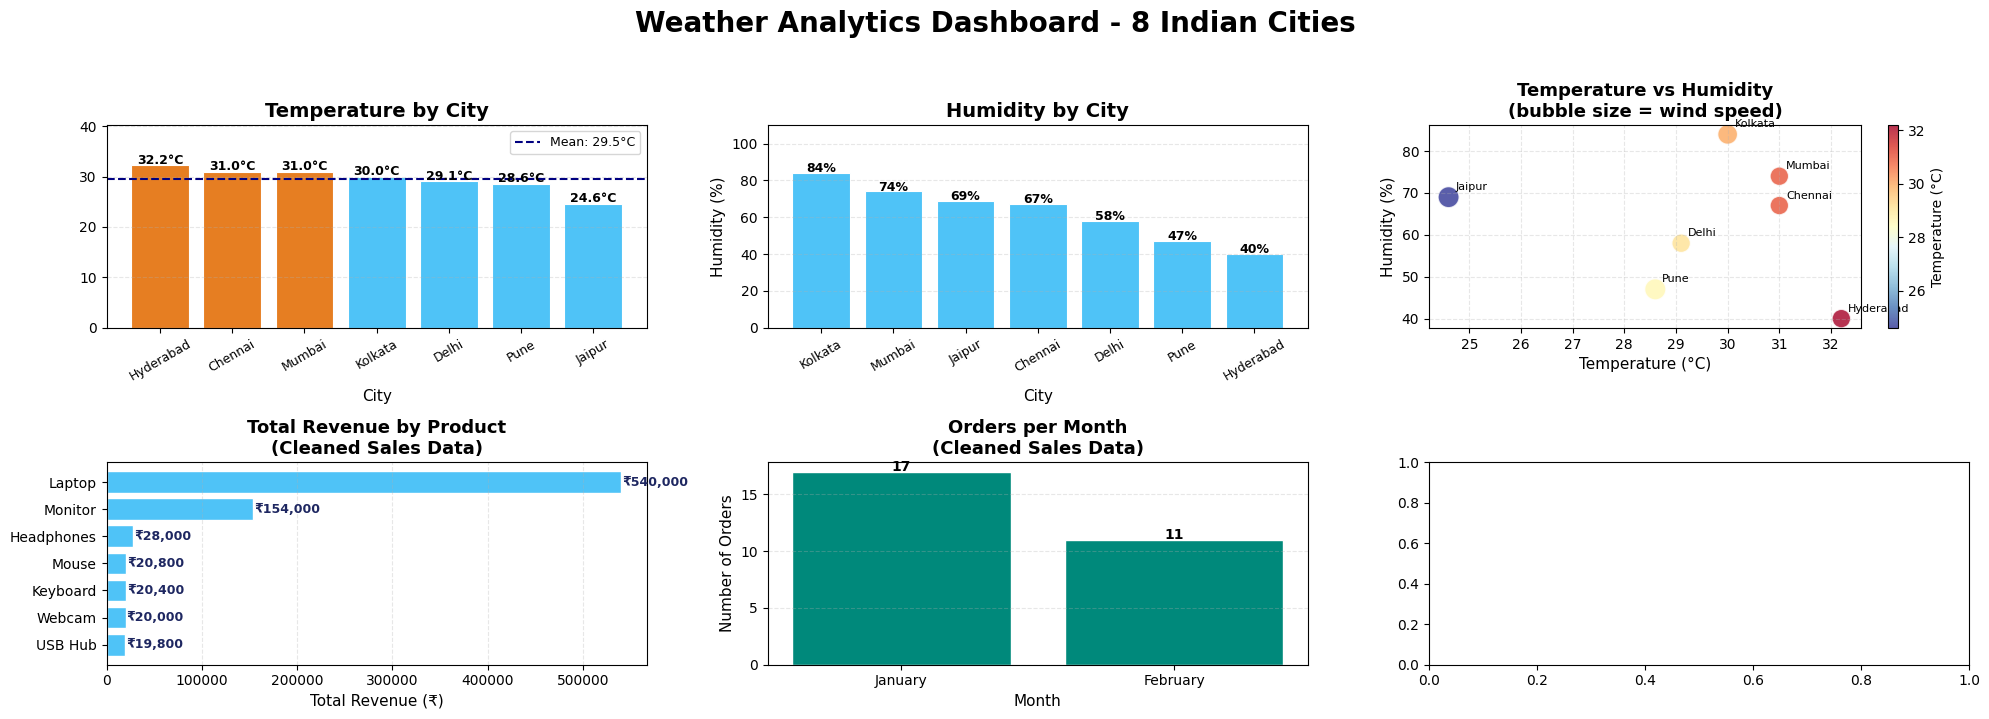

Dashboard saved as: weather_dashboard.png


In [48]:
fig, axes = plt.subplots(2,3,figsize=(20,7))       # layout = 2rows, 3columns, 20x7 inches  , fig->whole dashboard, axes-> individual charts
fig.suptitle('Weather Analytics Dashboard - 8 Indian Cities', fontsize=20, fontweight='bold',y=1.02)    # dashboard title

wdf =weather_df.sort_values('temperature',ascending=False)  # sort cities by temperature

# PLOT 1
ax1 = axes[0][0]    #top-left chart
colors_temp =['#E74C3C' if t >35 else '#E67E22' if t>30 else '#4FC3F7'     # temp >35 ->red , >30 orange,else blue
for t in wdf['temperature']]

bars1 = ax1.bar(wdf['city'],wdf['temperature'],
                color=colors_temp, edgecolor='white', linewidth=0.8)
for bar in bars1:                       # each bar
  ax1.text(bar.get_x()+                 # text->write text on chart , get_x -> left edge of the bar
           bar.get_width()/2,           # width, /2 -> center of bar
           bar.get_height()+0.3,        # return height , with +0.3 text align above the bar
           f'{bar.get_height()}°C',     # display above the bar
           ha='center',                 # center the text
           fontsize=9,
           fontweight='bold')
ax1.set_title('Temperature by City',fontsize=14, fontweight='bold')
ax1.set_xlabel('City',fontsize=11)
ax1.set_ylim(0, max(wdf['temperature']) + 8)
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=wdf['temperature'].mean(), color='navy',
            linestyle='--', linewidth=1.5, label=f"Mean: {wdf['temperature'].mean():.1f}°C")
ax1.legend(fontsize=9)

ax2 = axes[0][1]
wdf_hum = weather_df.sort_values('humidity', ascending=False)
bars2 = ax2.bar(wdf_hum['city'], wdf_hum['humidity'],
                color='#4FC3F7', edgecolor='white', linewidth=0.8)
for bar in bars2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{int(bar.get_height())}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Humidity by City', fontsize=14, fontweight='bold')
ax2.set_xlabel('City', fontsize=11)
ax2.set_ylabel('Humidity (%)', fontsize=11)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=30, labelsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

ax3 = axes[0][2]
scatter = ax3.scatter(
    weather_df['temperature'],
    weather_df['humidity'],
    s=weather_df['wind_speed'] * 50,
    c=weather_df['temperature'],
    cmap='RdYlBu_r',
    alpha=0.8,
    edgecolors='white', linewidth=1
)


for _, row in weather_df.iterrows():
    ax3.annotate(row['city'],
                 (row['temperature'], row['humidity']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.colorbar(scatter, ax=ax3, label='Temperature (°C)')
ax3.set_title('Temperature vs Humidity\n(bubble size = wind speed)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Temperature (°C)', fontsize=11)
ax3.set_ylabel('Humidity (%)', fontsize=11)
ax3.grid(alpha=0.3, linestyle='--')



ax1 = axes[1][0]
product_rev_sorted = product_rev.sort_values('revenue', ascending=True)


bars = ax1.barh(product_rev_sorted['product'],
                product_rev_sorted['revenue'],
                color='#4FC3F7', edgecolor='white')
for bar in bars:
    ax1.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():,.0f}',
             va='center', fontsize=9, fontweight='bold', color='#1E2761')
ax1.set_title('Total Revenue by Product\n(Cleaned Sales Data)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Revenue (₹)', fontsize=11)
ax1.grid(axis='x', alpha=0.3, linestyle='--')


ax2 = axes[1][1]
monthly = df.groupby('month_name')['order_id'].count().reset_index()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly['month_num'] = monthly['month_name'].map({m:i for i,m in enumerate(month_order)})
monthly = monthly.sort_values('month_num')

ax2.bar(monthly['month_name'], monthly['order_id'],
        color='#00897B', edgecolor='white')
for bar in ax2.patches:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Orders per Month\n(Cleaned Sales Data)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')



plt.tight_layout()
plt.savefig('weather_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as: weather_dashboard.png')


--END OF MINIPROJECT DAY-3--